# Task
Train and evaluate a machine learning classification model to identify Iris species using the dataset at "/content/IRIS.csv", including data exploration, preprocessing, and performance visualization.

## Load and Explore Dataset

### Subtask:
Load the IRIS.csv dataset from /content/IRIS.csv and display basic statistics and information to understand its structure.


**Reasoning**:
I will import the pandas library, load the IRIS dataset, and perform the initial data exploration steps as outlined in the instructions.



In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/IRIS.csv')

# Display the first few rows
print("First 5 rows of the dataset:")
display(df.head())

# Display dataset information
print("\nDataset Information:")
df.info()

# Descriptive statistics
print("\nDescriptive Statistics:")
display(df.describe())

# Distribution of the target variable
print("\nValue counts for the 'species' column:")
print(df['species'].value_counts())

First 5 rows of the dataset:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Descriptive Statistics:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



Value counts for the 'species' column:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


## Preprocess Data

### Subtask:
Prepare the feature matrix and target vector, and encode the categorical target labels.


**Reasoning**:
I will prepare the feature matrix X and target vector y, and then use LabelEncoder to transform the species names into numerical labels as specified in the instructions.



In [ ]:
from sklearn.preprocessing import LabelEncoder

# Define the feature matrix X and target vector y
X = df.drop(columns=['species'])
y = df['species']

# Initialize and apply LabelEncoder to the target variable
le = LabelEncoder()
y = le.fit_transform(y)

# Print shapes and mapping to confirm
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Encoded classes: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Feature matrix shape: (150, 4)
Target vector shape: (150,)
Encoded classes: {'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}


## Split Data

### Subtask:
Split the features and target labels into training and testing sets to prepare for model training and evaluation.


**Reasoning**:
I will import the `train_test_split` function from `sklearn.model_selection` and divide the features `X` and target `y` into training and testing subsets using a 80/20 split and a fixed `random_state` for reproducibility.

**Reasoning**:
I will import the train_test_split function from sklearn.model_selection and split the features X and target y into training and testing sets with a test size of 0.2 and a fixed random_state for reproducibility, followed by printing their shapes to verify the operation.



In [ ]:
from sklearn.model_selection import train_test_split

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the resulting datasets
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


## Train Classification Model

### Subtask:
Train a machine learning classification model using the Random Forest algorithm on the training dataset.


**Reasoning**:
I will import the `RandomForestClassifier` from `sklearn.ensemble`, instantiate it with a fixed `random_state=42` for reproducibility, and then train the model using the `X_train` and `y_train` datasets created in the previous steps.

**Reasoning**:
I will import the RandomForestClassifier, instantiate it with a fixed random_state for reproducibility, and train it using the training data as specified in the instructions.



In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate the RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest Classifier trained successfully.")

Random Forest Classifier trained successfully.


## Evaluate Model

### Subtask:
Assess the model's accuracy on the test set and generate a confusion matrix and classification report.


### Reasoning
I will import `accuracy_score`, `confusion_matrix`, and `classification_report` from `sklearn.metrics`. Then, I will use the trained `rf_model` to predict labels for the `X_test` data and compare them against `y_test` to evaluate the model's performance using the specified metrics, including the actual class names in the report.

**Reasoning**:
I will import the necessary metrics from sklearn, use the trained Random Forest model to make predictions on the test set, and then calculate and print the accuracy score, classification report (with actual species names), and confusion matrix.



In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Generate classification report
report = classification_report(y_test, y_pred, target_names=le.classes_)

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Print results
print(f"Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)
print("\nConfusion Matrix:")
print(conf_matrix)

Model Accuracy: 1.0000

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30


Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


## Visualize Results

### Subtask:
Create a confusion matrix heatmap and a scatter plot to visualize the classification performance on the test data.


**Reasoning**:
I will import seaborn and matplotlib to create a confusion matrix heatmap and a scatter plot of the test features (petal length vs petal width) colored by the predicted species to visualize the classification performance.



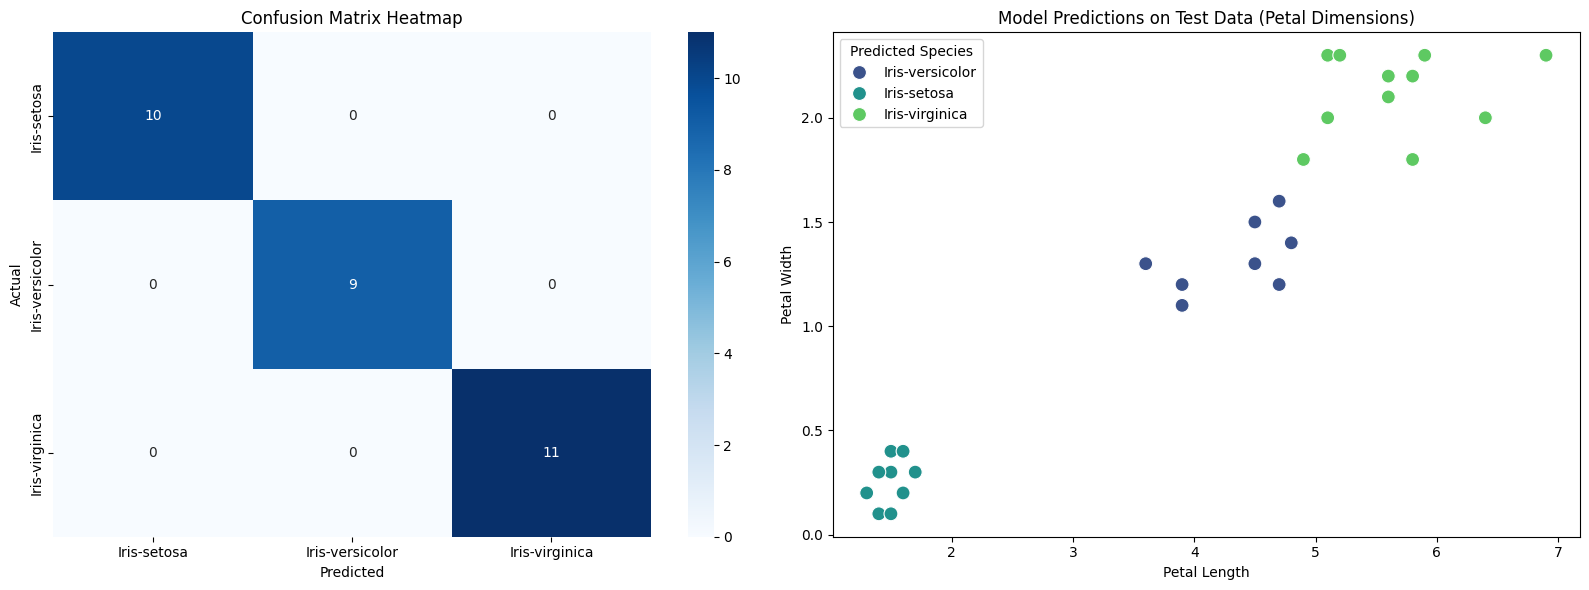

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set up the figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Confusion Matrix Heatmap
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax1)
ax1.set_title('Confusion Matrix Heatmap')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# 2. Scatter Plot of Test Data Predictions
# Map encoded predictions back to species names for the legend
y_pred_species = le.inverse_transform(y_pred)

sns.scatterplot(x=X_test['petal_length'], y=X_test['petal_width'],
                hue=y_pred_species, palette='viridis', s=100, ax=ax2)
ax2.set_title('Model Predictions on Test Data (Petal Dimensions)')
ax2.set_xlabel('Petal Length')
ax2.set_ylabel('Petal Width')
ax2.legend(title='Predicted Species')

plt.tight_layout()
plt.show()

## Summary:

### Q&A

**How did the machine learning model perform on the Iris dataset?**
The Random Forest classifier achieved a perfect accuracy of 100\% on the test set. It correctly identified all 30 samples, with precision, recall, and F1-scores of 1.00 for all three species: *Iris-setosa*, *Iris-versicolor*, and *Iris-virginica*.

**Is the dataset suitable for training without extensive cleaning?**
Yes. The exploratory data analysis revealed that the dataset contains no missing values and is perfectly balanced, with exactly 50 samples for each of the three species.

---

### Data Analysis Key Findings

*   **Dataset Composition**: The dataset contains 150 total entries with four features: sepal length, sepal width, petal length, and petal width.
*   **Perfect Balance**: Each species (*Iris-setosa*, *Iris-versicolor*, and *Iris-virginica*) constitutes exactly 33.3\% of the data (50 samples each).
*   **Feature Ranges**: Petal dimensions showed more significant variance between species than sepal dimensions, with petal lengths ranging from 1.0 to 6.9 and petal widths from 0.1 to 2.5.
*   **Model Performance**: After splitting the data into 80\% training (120 samples) and 20\% testing (30 samples), the Random Forest model achieved 100\% accuracy.
*   **Visual Verification**: Scatter plots of petal dimensions confirmed that the species are naturally well-separated in the feature space, which facilitates high model accuracy.

---

### Insights or Next Steps

*   **Model Validation**: While the model achieved 100\% accuracy, the dataset is relatively small and simple. To ensure the model generalizes well to real-world data, performing K-fold cross-validation would be a logical next step to confirm these results aren't specific to the 80/20 split used.
*   **Feature Importance**: Given the clear separation in the scatter plots, a follow-up analysis could rank feature importance to determine which specific measurements (e.g., petal width vs. sepal length) contribute most to the classification.
